In [1]:
import pandas as pd
import re
import numpy as np
import seaborn as sns

In [2]:
# загружаем данные из Roistat
results = pd.read_csv('results_3_clean.csv')

In [3]:
# переименовываем интересующие нас колонки
results = results.rename(columns={'Источник (уровень 1)': 'source', 'Источник (уровень 4)' : 'vk_offer','Источник (уровень 5)' : 'yandex_offer', 
                        'Расходы':'costs', 'Показы' : 'impressions', 'Визиты' : 'clicks', 'Заявки' : 'leads', 
                        'Целевой (пользовательский)' : 'q_leads', 'Продажи' : 'sales'})

Посмотрим, как выглядят данные в таблице results. Это данные из Roistat по рекламным результатам для находящегося на этапе строительства дома бизнес-класса за последние 3 месяца.  
Некоторые значения в датасете анонимизированы (****) для сохранения конфиденциальности проекта  

In [5]:
results.head(2)

,source,Источник (уровень 1) значение,Источник (уровень 3),Источник (уровень 3) значение,vk_offer,Источник (уровень 4) значение,yandex_offer,Источник (уровень 5) значение,Источник (уровень 6),Источник (уровень 6) значение,...,CPO (план) (пользовательский),Мультиканальные заявки,Конверсия в продажи,sales,Выручка,Прибыль,ROI,Средний чек,"ДРР, %",Показатель отказов
0,VK Ads,vkads8,"Супергео 1,5 км, 24-60, ****",116047411,3.1.16. Фасад | Рассрочка 0%,190494006,NaN,NaN,NaN,NaN,...,0,0,0.0,0,0,0,-1.0,0.0,0.0,0.0
1,Я.Директ,direct9,9.1 Сети | СуперГео | **** | ЧЛ,120103534,9.10 ******** 2к,5582149845,"Двухкомнатные на ********, ** с премиальной от...",17022611907,2 комнатная ********,2 комнатная ********,...,0,0,0.0,0,0,0,-1.0,0.0,0.0,0.4


In [6]:
# фильтруем данные по Яндекс.Директу для анализа
direct = results[[ 'yandex_offer', 'costs', 'impressions', 'clicks', 'leads', 'q_leads', 'sales']] \
                .loc[results['source'] == 'Я.Директ']

In [7]:
direct.head()

,yandex_offer,costs,impressions,clicks,leads,q_leads,sales
1,"Двухкомнатные на ********, ** с премиальной от...",746.6616,5359,20,1,0,0
2,Квартиры с террасами в самом центре ****а. Рас...,6715.3524,34236,151,1,0,0
4,"Квартиры бизнес-класса в центре ****а от 6,7 м...",977.3400,6337,16,1,0,0
5,"Квартиры бизнес-класса в центре ****а от 6,7 м...",900.3216,5753,25,1,1,0
7,Квартиры бизнес-класса в доме на ******** ** о...,993.2880,2,2,1,0,0


In [8]:
# группируем данные по офферу в заголовке и агрегируем данные по ним
direct_table = direct.groupby('yandex_offer') \
      .agg({'costs' : 'sum', 'impressions' : 'sum', 'clicks' : 'sum', 'leads' : 'sum', 'q_leads' : 'sum'}) \
      .reset_index() \
      .sort_values('costs', ascending = False)

In [9]:
# посмотрим количество получившихся офферов
direct_table.shape

(292, 6)

In [10]:
# округляем расходы
direct_table['costs'] = direct_table['costs'].round().astype(int)

In [11]:
direct_table.head()

,yandex_offer,costs,impressions,clicks,leads,q_leads
248,Объявление Мастер кампаний,681017,4237693,36406,136,36
273,Строящиеся квартиры в центре ****а с отделкой ...,249206,1107865,6017,38,19
226,Квартиры с террасами в самом центре ****а. Рас...,208785,1588690,6000,29,9
137,Квартиры бизнес-класса в центре ****а от 7 млн ₽,124252,918488,3630,8,4
199,Квартиры в центре ****а с премиальной отделкой...,81691,499236,2062,10,2


In [12]:
# считаем по готовым данным CTR, CPL, % перехода в лиды, CPQ, % перехода в целевые
direct_table.insert(
    direct_table.columns.get_loc('clicks') + 1,
    'ctr',
    direct_table['clicks'] / direct_table['impressions'] * 100
)

direct_table.insert(
    direct_table.columns.get_loc('leads') + 1,
    'cpl',
    np.where(direct_table['leads'] != 0, direct_table['costs'] / direct_table['leads'], 0)
)

direct_table.insert(
    direct_table.columns.get_loc('cpl') + 1,
    'cr_leads',
    np.where(direct_table['leads'] != 0, direct_table['leads'] / direct_table['clicks'] * 100, 0)
)

direct_table.insert(
    direct_table.columns.get_loc('q_leads') + 1,
    'cpq',
    np.where(direct_table['q_leads'] != 0, direct_table['costs'] / direct_table['q_leads'], 0)
)

direct_table.insert(
    direct_table.columns.get_loc('cpq') + 1,
    'cr_q_leads',
    np.where(direct_table['q_leads'] != 0, direct_table['q_leads'] / direct_table['leads'] * 100, 0)
)

In [13]:
# округляем все созданные столбцы. CR - до 2 знаков после запятой, так как это %
direct_table['ctr'] = direct_table['ctr'].round(2)
direct_table['cr_leads'] = direct_table['cr_leads'].round(2)
direct_table['cr_q_leads'] = direct_table['cr_q_leads'].round(2)

# округляем денежные столбцы и приводим к типу целое
direct_table['cpl'] = direct_table['cpl'].round(0).astype(int)
direct_table['cpq'] = direct_table['cpq'].round(0).astype(int)

In [14]:
# следующие офферы принесли больше всего лидов
# объявления из Мастера кампаний можно анализировать только в Яндекс Директе, поэтому их не учитываем
direct_table.head()

,yandex_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
248,Объявление Мастер кампаний,681017,4237693,36406,0.86,136,5007,0.37,36,18917,26.47
273,Строящиеся квартиры в центре ****а с отделкой ...,249206,1107865,6017,0.54,38,6558,0.63,19,13116,50.00
226,Квартиры с террасами в самом центре ****а. Рас...,208785,1588690,6000,0.38,29,7199,0.48,9,23198,31.03
137,Квартиры бизнес-класса в центре ****а от 7 млн ₽,124252,918488,3630,0.40,8,15532,0.22,4,31063,50.00
199,Квартиры в центре ****а с премиальной отделкой...,81691,499236,2062,0.41,10,8169,0.48,2,40846,20.00


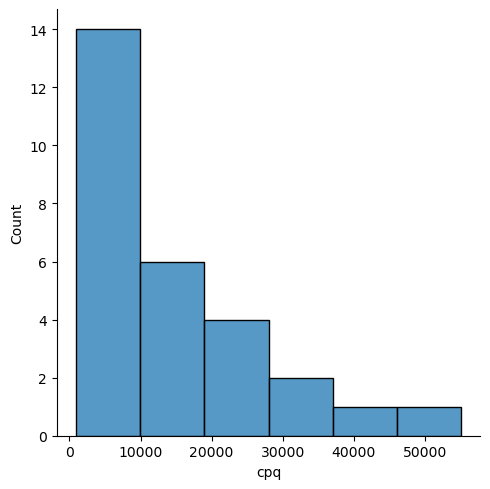

In [15]:
# посмотрим на распределение cpq на графике
sns.displot(data=direct_table.query('cpq>0'), x="cpq")

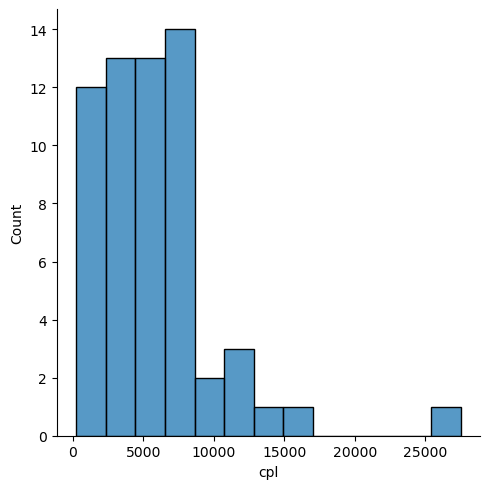

In [188]:
# посмотрим на распределение cpl на графике
sns.displot(data=direct_table.query('cpl>0'), x="cpl")

#### Для дальнейшего сравнения офферов рассчитаем средние показатели по всем объявлениям

In [94]:
# рассчитаем среднюю цену лида
round(direct_table.costs.sum() / direct_table.leads.sum(), 0)

7135.0

In [96]:
# средняя цена целевого
round(direct_table.costs.sum() / direct_table.q_leads.sum(), 0)

23524.0

In [98]:
# средний процент CR в целевые лиды
round(direct_table.q_leads.sum() / direct_table.leads.sum() * 100, 2)

30.33

#### Топ-10 заголовков по количеству лидов:
Рассмотрим офферы с наибольшим количеством лидов, так как накопленных данных по ним достаточно для формирования более устойчивых выводов

In [17]:
direct_table.query('leads > 0').sort_values('leads', ascending = False).head(10)

,yandex_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
248,Объявление Мастер кампаний,681017,4237693,36406,0.86,136,5007,0.37,36,18917,26.47
273,Строящиеся квартиры в центре ****а с отделкой ...,249206,1107865,6017,0.54,38,6558,0.63,19,13116,50.00
226,Квартиры с террасами в самом центре ****а. Рас...,208785,1588690,6000,0.38,29,7199,0.48,9,23198,31.03
199,Квартиры в центре ****а с премиальной отделкой...,81691,499236,2062,0.41,10,8169,0.48,2,40846,20.00
137,Квартиры бизнес-класса в центре ****а от 7 млн ₽,124252,918488,3630,0.40,8,15532,0.22,4,31063,50.00
133,"Квартиры бизнес-класса в центре ****а от 6,04 ...",34156,174735,856,0.49,8,4270,0.93,1,34156,12.50
135,"Квартиры бизнес-класса в центре ****а от 6,96 ...",45989,311403,1241,0.40,7,6570,0.56,2,22994,28.57
186,Квартиры в центре ****а. 3 варианта отделки на...,45864,368620,1547,0.42,6,7644,0.39,0,0,0.00
244,Новостройка в центре ****а. Ипотека от 20 821 ...,14899,73476,292,0.40,5,2980,1.71,2,7450,40.00
134,"Квартиры бизнес-класса в центре ****а от 6,7 м...",4688,30019,122,0.41,5,938,4.10,3,1563,60.00


- Самое конвертящее лиды объявление - про строящиеся кватиры с отделкой White Box
- Здесь наблюдается большой CPQ для оффера "квартиры с премиальной отделкой", а также можно отметить, что у оффера "3 варианта отделки на выбор" не было качественных лидов, поэтому их рекомендуется исключить из рекламных кампаний в ближайшее время.
- Для объявления с ценой от 7 млн CPL значительно выше, чем для аналогичных формулировок с ценой от 6 млн, что может указывать на чувствительность аудитории к цене. Проверим, что в офферах с ценой от 7 млн рублей, не было лучших результатов

In [19]:
# В выгрузке из Roistat обычные пробелы в заголовках заменены на неразрывные (\xa0), поэтому поиск по строке выполняется через '\xa07\xa0млн'
direct_table[direct_table['yandex_offer'].str.contains('\xa07\xa0млн', na=False)].loc[direct_table['leads']>0]

,yandex_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
137,Квартиры бизнес-класса в центре ****а от 7 млн ₽,124252,918488,3630,0.40,8,15532,0.22,4,31063,50.0
118,Квартиры бизнес-класса в доме на ******** ** о...,11822,357,90,25.21,1,11822,1.11,0,0,0.0
213,Квартиры от застройщика в центре ****а от 7 млн ₽,3536,14327,34,0.24,2,1768,5.88,0,0,0.0


- В 1 объявлении с оффером "от 7 млн" было 2 лида по 1 768 рублей, но они некачественные. В дальнейших РК рекомендуется избегать акцента на цене «от 7 млн ₽» в заголовках и по возможности использовать более низкий ценовой порог, поскольку повышение минимальной цены в оффере, вероятно, будет ухудшать эффективность кампаний.

#### Топ-10 заголовков с самым дешевым CPQ:

In [22]:
direct_table.query('q_leads > 0').sort_values('cpq').head(10)

,yandex_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
242,Новостройка в центре ****а. Ипотека от 20 181 ...,953,5981,24,0.40,1,953,4.17,1,953,100.0
29,2-комнатные на ******** **. Ипотека от 26 471 ...,1217,39,14,35.90,1,1217,7.14,1,1217,100.0
134,"Квартиры бизнес-класса в центре ****а от 6,7 м...",4688,30019,122,0.41,5,938,4.10,3,1563,60.0
41,2 комнатные квартиры в Ленинском районе с отде...,1884,12580,58,0.46,1,1884,1.72,1,1884,100.0
131,Квартиры бизнес-класса в центре ****а в рассро...,3454,31184,552,1.77,1,3454,0.18,1,3454,100.0
82,Дом на ******** **. Скидка за наличный расчет ...,7187,180,57,31.67,4,1797,7.02,2,3594,50.0
1,1-комнатные на ******** **. Ипотека от 20 821 ...,3680,3941,62,1.57,1,3680,1.61,1,3680,100.0
232,Квартиры с террасами на ******** ** в центре *...,4567,34505,140,0.41,1,4567,0.71,1,4567,100.0
52,3 комн. квартиры в центре ****а в доме бизнес-...,6240,1484,33,2.22,1,6240,3.03,1,6240,100.0
117,Квартиры бизнес-класса в доме на ******** ** о...,6562,116,49,42.24,1,6562,2.04,1,6562,100.0


- Среди объявлений с самым дешевым CPQ 30% объявлений - про ипотеку, но при этом комнатность у всех разная.  
- Больше 1 целевого лида принесли офферы "Квартиры с ценой от 6,7 млн" и "Дом...скидка за наличный расчет". Но поскольку среди всех объявлений с самым низким CPQ для каждого из них в отдельности сумма расходов менее 10 000 рублей, такие дешевые результаты скорее обусловлены их недолгим показом, а не стабильной результативностью, которую можно масштабировать

### Сформируем категории офферов
Получившаяся таблица direct_table показывает результаты только на уровне конкретных объявлений и отдельных формулировок заголовков в Яндексе. Так как тестируются разные заголовки и цифры в них меняются каждый месяц, то в целом за 3 месяца получилось довольно большое количество (292) разных отличающихся друг от друга офферов


Поэтому приняла решение проанализировать более общие смысловые группы, чтобы клиент мог понимать, какие типы квартир, условия покупки или ценностные предложения работали лучше за всё время

In [27]:
# прописываем функцию, которая приведет все офферы к нижнему регистру
def normalize(text):
    if pd.isna(text):
        return ''
    return str(text).lower()

На основе датасета пришла к выводу, что все заголовки можно условно подразделить по смыслу на "тип квартиры" + "конкрентный оффер с цифрами или без"

Для типа квартиры выделила следующие возможные группы: 1-комнатные, евродвушки, 2-комнатные, 3-комнатные, квартиры от застрощийка, новостройки (квартиры в новостройке или просто с формулировкой "Новостройка"), строящиеся ("строящиеся квартиры" или "квартиры на этапе строительства"), квартиры с террасами, дом (для формулировок "Дом на ул." или "Дом бизнес-класса", мастер (для объявлений из Мастера кампаний) и квартиры (для всех остальных формулировок, где не упоминается ничего вышеперечисленное)

In [29]:
# прописываем функцию, которая определит тип квартиры, про который идет речь в объявлении
def get_type_rooms(text):
    text = normalize(text)
    
    if re.search(r'(1[-\s]?к|1[-\s]?комн|однуш|однокомнат)', text):
        return '1-комнатные'
    elif re.search(r'(евро[-\s]?2[-\s]?к|евро[-\s]?2[-\s]?комн|евродвуш)', text):
         return 'евродвушки'
    elif re.search(r'(2[-\s]?к|2[-\s]?комн|двуш|двухкомнат|евродвуш)', text):
        return '2-комнатные'
    elif re.search(r'(3[-\s]?к|3[-\s]?комн|треш|трехкомнат)', text):
        return '3-комнатные'
    elif 'застройщик' in text:
        return 'квартиры от застройщика'
    elif 'новостройк' in text:
        return 'новостройка'
    elif 'строящ' in text or 'строительст' in text:
        return 'строящиеся'
    elif 'террас' in text:
        return 'квартиры с террасами'    
    elif 'дом' in text:
        return 'дом'
    elif 'мастер' in text:
        return 'мастер'
    else:
        return 'квартиры'

Для офферов также выделила возможные группы и как найти такие объявления: ипотека, скидка за наличные (скидка указана в %), скидка в рублях, цена, рассрочка, whitebox, премиальная отделка, с отделкой (без упоминания предчистовой или премиальной), кампаний (для объявлений Мастера кампаний) и без оффера

In [31]:
# прописываем функцию, который определит основной оффер в объявлении
def get_offer(text):
    text = normalize(text)

    if 'ипотек' in text or 'мес' in text:
        return 'ипотека'
    elif 'наличн' in text:
        return 'скидка за наличные'
    elif 'скидк' in text:
        return 'скидка в рублях'
    elif 'млн' in text:
        return 'цена'
    elif 'рассрочк' in text:
        return 'рассрочка'
    elif 'white' in text or 'box' in text or 'предчист' in text:
        return 'whitebox'
    elif 'премиальн' in text or 'премиум' in text or 'дизайнер' in text:
        return 'премиальная отделка'
    elif 'отделк' in text:
        return 'с отделкой'    
    elif 'кампаний' in text:
        return 'кампаний'       
    else:
        return 'без оффера'

In [32]:
# создаем столбцы и с помощью функции присваиваем каждому заголовку - тип квартиры, указанный в тексте, и основной оффер
direct_table['type_apartment'] = direct_table['yandex_offer'].apply(get_type_rooms)
direct_table['offer'] = direct_table['yandex_offer'].apply(get_offer)

In [33]:
# формируем столбец main_offer, где будет и тип квартиры, и основной оффер
direct_table['main_offer'] = direct_table['type_apartment'] + ' | ' + direct_table['offer']

In [34]:
# группируем данные по основному офферу и считаем основные показатели
direct_by_main_offer = direct_table.groupby('main_offer') \
            .agg({'costs' : 'sum', 'impressions' : 'sum', 'clicks' : 'sum', 'leads' : 'sum', 'q_leads' : 'sum'}) \
            .reset_index() \
            .sort_values('q_leads', ascending = False)

In [35]:
direct_by_main_offer.head()

,main_offer,costs,impressions,clicks,leads,q_leads
55,мастер | кампаний,681017,4237693,36406,136,36
62,строящиеся | whitebox,289819,1293304,7112,43,21
44,квартиры | цена,217359,1470995,6223,28,10
53,квартиры с террасами | рассрочка,247999,1975068,8133,32,9
36,квартиры | whitebox,78498,618930,2943,7,4


In [36]:
# добавляем CTR, CPL, % перехода в лиды, CPQ, % перехода в целевые в эту таблицу
direct_by_main_offer.insert(
    direct_by_main_offer.columns.get_loc('clicks') + 1,
    'ctr',
    direct_by_main_offer['clicks'] / direct_by_main_offer['impressions'] * 100
)

direct_by_main_offer.insert(
    direct_by_main_offer.columns.get_loc('leads') + 1,
    'cpl',
    np.where(direct_by_main_offer['leads'] != 0, direct_by_main_offer['costs'] / direct_by_main_offer['leads'], 0)
)

direct_by_main_offer.insert(
    direct_by_main_offer.columns.get_loc('cpl') + 1,
    'cr_leads',
    np.where(direct_by_main_offer['leads'] != 0, direct_by_main_offer['leads'] / direct_by_main_offer['clicks'] * 100, 0)
)

direct_by_main_offer.insert(
    direct_by_main_offer.columns.get_loc('q_leads') + 1,
    'cpq',
    np.where(direct_by_main_offer['q_leads'] != 0, direct_by_main_offer['costs'] / direct_by_main_offer['q_leads'], 0)
)

direct_by_main_offer.insert(
    direct_table.columns.get_loc('cpq') + 1,
    'cr_q_leads',
    np.where(direct_by_main_offer['q_leads'] != 0, direct_by_main_offer['q_leads'] / direct_by_main_offer['leads'] * 100, 0)
)

In [37]:
# округляем все созданные столбцы. cr - до 2 знаков после запятой, так как это %
direct_by_main_offer['ctr'] = direct_by_main_offer['ctr'].round(2)
direct_by_main_offer['cr_leads'] = direct_by_main_offer['cr_leads'].round(2)
direct_by_main_offer['cr_q_leads'] = direct_by_main_offer['cr_q_leads'].round(2)

# округляем денежные столбцы и приводим к типу целое
direct_by_main_offer['cpl'] = direct_by_main_offer['cpl'].round(0).astype(int)
direct_by_main_offer['cpq'] = direct_by_main_offer['cpq'].round(0).astype(int)

#### Определим категории офферов с самыми дорогими целевыми лидами:

In [130]:
direct_by_main_offer.query('q_leads > 0 & cpq >25000').sort_values('cpq', ascending = False)

,main_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
39,квартиры | премиальная отделка,115807,737581,3427,0.46,12,9651,0.35,2,57904,16.67
38,квартиры | ипотека,45928,149148,1181,0.79,5,9186,0.42,1,45928,20.00
52,квартиры с террасами | без оффера,43556,284600,1300,0.46,5,8711,0.38,1,43556,20.00
30,дом | цена,38008,218234,2272,1.04,3,12669,0.13,1,38008,33.33
40,квартиры | рассрочка,35418,198825,1930,0.97,4,8854,0.21,1,35418,25.00
10,2-комнатные | ипотека,68827,338831,1755,0.52,4,17207,0.23,2,34414,50.00
53,квартиры с террасами | рассрочка,247999,1975068,8133,0.41,32,7750,0.39,9,27555,28.12


- Категории с CPQ выше 30 000 ₽ на текущем этапе не рекомендуется использовать в дальнейших запусках: "квартиры | ипотека", "квартиры с террасами | без оффера", "дом | цена", "квартиры | рассрочка", "2-комнатные | ипотека"
- С категорией "квартиры с террасами | рассрочка" предлагаю поработать дальше, так как в целом она хорошо конвертирует в лиды, цена CPL чуть выше среднего, проблема в высоком CPQ, стоит посмотреть более детально статусы лидов и причины, по которым они отказались от дальнейшего общения, и формировать гипотезы для тестирования (возможно, стоит как-то отработать этот момент уже на посадочной странице)
- Категория "квартиры | премиальная отделка" также принесла большое количество лидов, но при этом у нее самый высокий CPQ среди всех. В текущем виде масштабировать данный оффер не рекомендуется. Но стоит проанализировать статусы лидов и определить причины, почему они перевелись в целевые. В качестве дальнейших гипотез можно протестировать более конкретные предложения — например, с указанием стоимости/ипотеки квартир с премиальной отделкой, так как на данный момент мы тестировали только упоминание премиальной отделки

#### Определим категории офферов с наибольшим количеством целевых лидов:

In [150]:
direct_by_main_offer.query('q_leads > 0').sort_values('q_leads', ascending = False).head(5)

,main_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
55,мастер | кампаний,681017,4237693,36406,0.86,136,5007,0.37,36,18917,26.47
62,строящиеся | whitebox,289819,1293304,7112,0.55,43,6740,0.60,21,13801,48.84
44,квартиры | цена,217359,1470995,6223,0.42,28,7763,0.45,10,21736,35.71
53,квартиры с террасами | рассрочка,247999,1975068,8133,0.41,32,7750,0.39,9,27555,28.12
36,квартиры | whitebox,78498,618930,2943,0.48,7,11214,0.24,4,19624,57.14


- Для масштабирования в дальнейших кампаниях целесообразно использовать офферы «строящиеся | whitebox», «квартиры | цена» и «квартиры | whitebox», так как они демонстрируют наилучший баланс между объемом целевых лидов и стоимостью их привлечения

#### Определим 5 категорий, которые не принесли лидов, но потратили больше всего:

In [39]:
direct_by_main_offer.sort_values('costs', ascending = False).query('leads == 0').head(5)

,main_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
16,2-комнатные | цена,19123,269812,2414,0.89,0,0,0.0,0,0,0.0
21,3-комнатные | рассрочка,14379,114066,512,0.45,0,0,0.0,0,0,0.0
35,евродвушки | цена,13939,91462,637,0.70,0,0,0.0,0,0,0.0
65,строящиеся | премиальная отделка,13154,32059,151,0.47,0,0,0.0,0,0,0.0
4,1-комнатные | рассрочка,12506,182980,1262,0.69,0,0,0.0,0,0,0.0


- От офферов "2-комнатные | цена" и "3-комнатные | рассрочка" рекомендую отказаться, так как они потратили уже x2 от средней цены лида.  
- По остальным категориям в таблице ("евродвушки | цена", "строящиеся | премиальная отделка", "1-комнатные | рассрочка") еще можно попробовать другие формулировки, но не приоритезировать их

#### Определим 5 категорий, которые не принесли целевые лиды, но потратили больше всего:

In [114]:
direct_by_main_offer.sort_values('costs', ascending = False).query('q_leads == 0').head(5)

,main_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
41,квартиры | с отделкой,62986,489133,2108,0.43,6,10498,0.28,0,0,0.0
31,евродвушки | ипотека,30506,107777,729,0.68,2,15253,0.27,0,0,0.0
8,2-комнатные | whitebox,25378,116826,589,0.50,3,8459,0.51,0,0,0.0
43,квартиры | скидка за наличные,25236,216212,1413,0.65,3,8412,0.21,0,0,0.0
16,2-комнатные | цена,19123,269812,2414,0.89,0,0,0.00,0,0,0.0


- Категории "квартиры | с отделкой", "евродвушки | ипотека", "2-комнатные | whitebox", "квартиры | скидка за наличные" рекомендуется больше не использовать, так как они потратили больше, чем средняя цена целевого, и не принесли ни одного целевого лида

#### Определим наиболее перспективные категории офферов, которые пока не принесли лиды:

Для определения перспективных направлений масштабирования были отобраны категории с устойчивым CTR при достаточном объеме данных (от 10 000 показов и/или от 100 кликов), а также учтен средний CTR для всех данных.


In [196]:
direct_by_main_offer.sort_values('impressions', ascending = False).query('ctr > 0.7 & impressions > 10000 & clicks > 100 & leads == 0').head(5)

,main_offer,costs,impressions,clicks,ctr,leads,cpl,cr_leads,q_leads,cpq,cr_q_leads
16,2-комнатные | цена,19123,269812,2414,0.89,0,0,0.0,0,0,0.0
27,дом | рассрочка,10362,208297,2465,1.18,0,0,0.0,0,0,0.0
68,строящиеся | цена,11614,207256,3865,1.86,0,0,0.0,0,0,0.0
7,1-комнатные | цена,9062,94488,2456,2.60,0,0,0.0,0,0,0.0
23,3-комнатные | цена,3951,65019,625,0.96,0,0,0.0,0,0,0.0


- Наиболее стабильные результаты демонстрируют категории «строящиеся | цена», «дом | рассрочка», «1-комнатные | цена» и «2-комнатные | цена». Эти направления характеризуются высоким объемом трафика и стабильной кликабельностью, что делает их приоритетными для расширения семантики и увеличения количества объявлений.

### Основные выводы

#### По конкретным заголовкам
- Самое конвертящее лиды объявление «Строящиеся квартиры в центре Кирова с отделкой White Box» - 38 лидов по 6 558 ₽, 19 целевых по 13 116 ₽. Рекомендуется использовать в дальнейших РК и масштабировать.
- Формулировки «Квартиры в центре Кирова с премиальной отделкой на выбор» и «Квартиры в центре Кирова. 3 варианта отделки на выбор» рекомендуется исключить из-за низкой эффективности.
- Выявлена чувствительность аудитории к цене. В дальнейших РК рекомендуется избегать акцента на цене «от 7 млн ₽» в заголовках и по возможности использовать более низкий ценовой порог, поскольку повышение минимальной цены в оффере, вероятно, будет ухудшать эффективность кампаний.
- 2 целевых лида по 3 594 ₽ у заголовка «Дом на ******* **. Скидка за наличный расчет до 5%», но расходы еще недостаточно большие, чтобы можно было делать вывод об устойчивых результатах, поэтому продолжаем тестирование оффера и наблюдаем за эффективностью.
#### По категориям
- В дальнейших запусках рекомендуется использовать следующие связки офферов: «строящиеся | whitebox», «квартиры | цена», «квартиры | whitebox», поскольку они показали наилучшие результаты по количеству целевых лидов при приемлемой стоимости целевого обращения.
- Категории с CPQ выше 30 000 ₽ на текущем этапе не рекомендуется использовать в дальнейших запусках: «квартиры | ипотека», «квартиры с террасами | без оффера», «дом | цена», «квартиры | рассрочка», «2-комнатные | ипотека»
-  Категории «квартиры | с отделкой», «евродвушки | ипотека», «2-комнатные | whitebox», «квартиры | скидка за наличные», «2-комнатные | цена» и «3-комнатные | рассрочка» рекомендуется больше не использовать
- Категории объявлений «квартиры с террасами | рассрочка» и «квартиры | премиальная отделка» требуют дальнейшего анализа качества и определения причин отказа клиента от общения с отделом продаж. После чего рекомендуется выдвинуть гипотезы о возможных изменениях на сайт / в формулировку заголовка
- Категории «строящиеся | цена», «дом | рассрочка», «1-комнатные | цена» и «2-комнатные | цена» показывают стабильный CTR и высокий объем трафика, но пока не дают лидов. Их целесообразно продолжать показывать в приоритетном режиме и дополнительно мониторить эффективность по мере накопления данных.